# Data makanan dan minuman (misalnya: data jenis makanan, penjualan F&B)


Sumber dataset: https://www.kaggle.com/datasets/sebastianwillmann/beverage-sales

# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset **tanpa label** dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.
   
2. **Ketentuan Dataset**:
   - **Tanpa label**: Dataset tidak boleh memiliki label atau kelas.
   - **Jumlah Baris**: Minimal 1000 baris untuk memastikan dataset cukup besar untuk analisis yang bermakna.
   - **Tipe Data**: Harus mengandung data **kategorikal** dan **numerikal**.
     - *Kategorikal*: Misalnya jenis kelamin, kategori produk.
     - *Numerikal*: Misalnya usia, pendapatan, harga.

3. **Pembatasan**:  
   Dataset yang sudah digunakan dalam latihan clustering (seperti customer segmentation) tidak boleh digunakan.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
# =============================================================
# Import Pustaka untuk Analisis Data & Visualisasi
# =============================================================
import pandas as pd  # Manipulasi dan analisis data
import matplotlib.pyplot as plt  # Visualisasi dalam bentuk grafik
import seaborn as sns  # Visualisasi interaktif dan lebih menarik

# =============================================================
# Import Pustaka untuk Clustering & Evaluasi Model
# =============================================================
from sklearn.cluster import KMeans, DBSCAN  # Algoritma clustering
from yellowbrick.cluster import KElbowVisualizer  # Menentukan jumlah klaster optimal (Elbow Method)
from sklearn.metrics import silhouette_score  # Evaluasi clustering dengan Silhouette Score

# =============================================================
# Import Pustaka untuk Preprocessing Data
# =============================================================
from sklearn.preprocessing import MinMaxScaler, StandardScaler  # Normalisasi & standarisasi data
from sklearn.preprocessing import LabelEncoder  # Encoding fitur kategorikal
from sklearn.decomposition import PCA  # Reduksi dimensi dengan Principal Component Analysis (PCA)

# =============================================================
# Import Pustaka untuk Feature Selection
# =============================================================
from sklearn.feature_selection import SelectKBest, mutual_info_regression  # Seleksi fitur berbasis informasi mutual

# =============================================================
# Import Modul OS untuk Manajemen File
# =============================================================
import os


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

In [2]:
# 1. Baca file CSV
df = pd.read_csv('synthetic_beverage_sales_data.csv')  # Gantilah dengan jalur file yang benar

# 2. Menampilkan 10 baris pertama dataset
print("Pratinjau 10 Baris Pertama Dataset:")
display(df.head(10))  # Menggunakan display() untuk tampilan lebih rapi di Jupyter Notebook/Colab


Pratinjau 10 Baris Pertama Dataset:


,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,ORD697566,CUS6363,B2C,Coca-Cola,Soft Drinks,1.04,7,0.00,7.28,Bremen,2021-02-17
1,ORD1118443,CUS7797,B2B,Selters,Water,0.71,46,0.10,29.39,Sachsen-Anhalt,2023-04-15
2,ORD742327,CUS3123,B2B,Fritz-Kola,Soft Drinks,2.90,73,0.05,201.11,Sachsen,2022-06-20
3,ORD1437128,CUS6393,B2B,Monster,Soft Drinks,2.68,30,0.05,76.38,Schleswig-Holstein,2021-09-07
4,ORD562794,CUS4090,B2C,San Pellegrino,Water,0.91,3,0.00,2.73,Hessen,2023-04-28
5,ORD2320519,CUS5936,B2C,Beck's,Alcoholic Beverages,1.41,4,0.00,5.64,Bremen,2023-11-01
6,ORD727051,CUS1935,B2C,San Pellegrino,Water,0.86,3,0.00,2.58,Berlin,2021-02-23
7,ORD2154629,CUS3548,B2C,Granini Apple,Juices,1.64,6,0.00,9.84,Rheinland-Pfalz,2022-04-16
8,ORD2893537,CUS155,B2B,Chardonnay,Alcoholic Beverages,9.12,18,0.05,155.95,Thüringen,2023-04-29
9,ORD1007101,CUS762,B2C,Cranberry Juice,Juices,3.56,14,0.00,49.84,Bayern,2022-11-10


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Menangani Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

1. Memahami Struktur Data

In [3]:
# Menampilkan informasi struktur dataset
print("Informasi awal dataset:")
df.info()

# Ambil sampel acak dari dataset jika terlalu besar
sample_size = 100_000  # Menggunakan underscore untuk keterbacaan angka
df_sampled = df.sample(n=sample_size, random_state=69).reset_index(drop=True)

# Menampilkan informasi dataset setelah sampling
print("\nInformasi dataset setelah sampling:")
df_sampled.info()


Informasi awal dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Order_ID       300000 non-null  object 
 1   Customer_ID    300000 non-null  object 
 2   Customer_Type  300000 non-null  object 
 3   Product        300000 non-null  object 
 4   Category       300000 non-null  object 
 5   Unit_Price     300000 non-null  float64
 6   Quantity       300000 non-null  int64  
 7   Discount       300000 non-null  float64
 8   Total_Price    300000 non-null  float64
 9   Region         300000 non-null  object 
 10  Order_Date     300000 non-null  object 
dtypes: float64(3), int64(1), object(7)
memory usage: 25.2+ MB

Informasi dataset setelah sampling:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         -----

2. Menangani Data yang Hilang

In [4]:
# 2. Menangani Data yang Hilang
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print("Jumlah data yang hilang per kolom:")
print(missing_values if not missing_values.empty else "Tidak ada data yang hilang.")

Jumlah data yang hilang per kolom:
Tidak ada data yang hilang.


3. Analisis Distribusi dan Korelasi

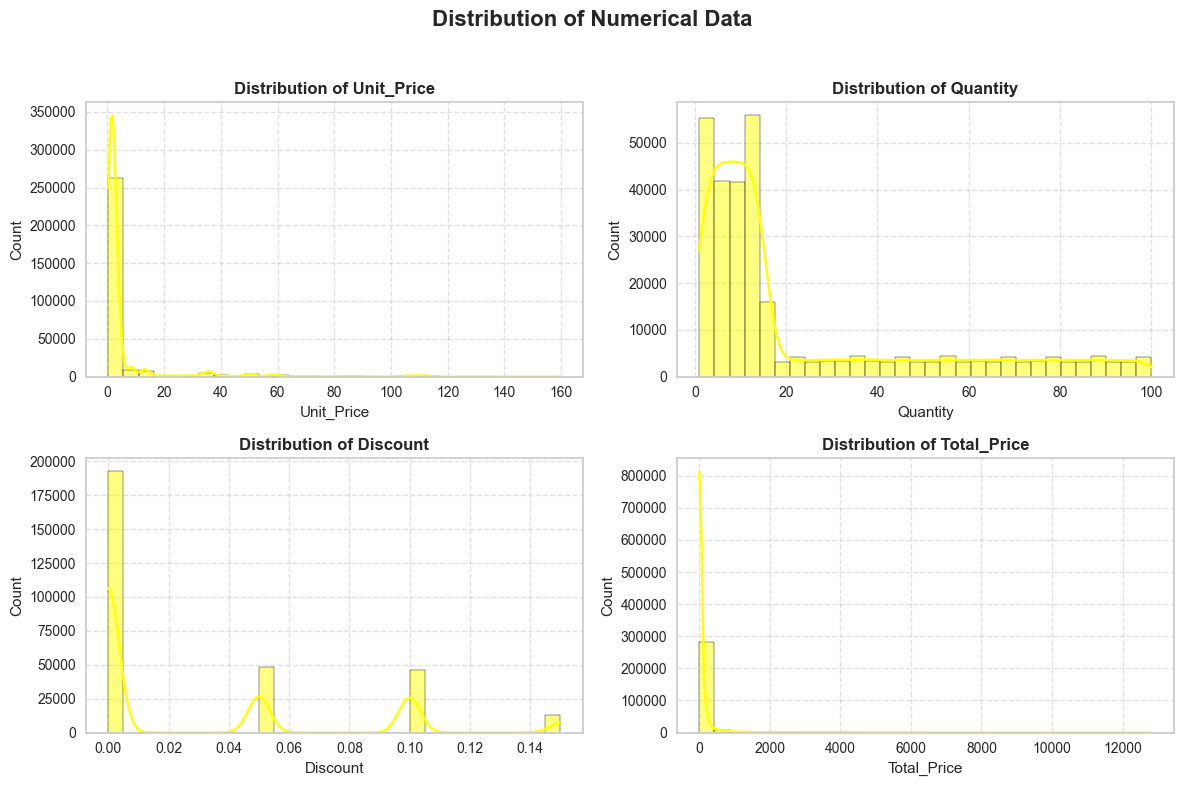

In [5]:
# Tampilkan ringkasan statistik untuk kolom data numerik
df.describe().apply(lambda x: x.apply('{0:.3f}'.format))

# Ambil nama kolom data numerik dari DataFrame
numeric_columns = df.select_dtypes(include=['number']).columns

# Tentukan jumlah baris dan kolom untuk subplot berdasarkan jumlah fitur
n = len(numeric_columns)
rows = (n // 2) + (n % 2)  # Mengatur jumlah baris agar fleksibel

# Buat figure dan axes dengan ukuran lebih luas
fig, axes = plt.subplots(rows, 2, figsize=(12, rows * 4))

# Flatten axes jika hanya ada satu baris
axes = axes.flatten() if n > 1 else [axes]

# Visualisasikan distribusi data numerik dalam histogram dengan KDE
for i, col in enumerate(numeric_columns):
    sns.histplot(df[col], ax=axes[i], kde=True, color='yellow', bins=30)
    axes[i].set_title(f"Distribution of {col}", fontsize=12, fontweight='bold')
    axes[i].grid(True, linestyle="--", alpha=0.6)

# Hapus subplot kosong jika jumlah kolom ganjil
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Tambahkan judul utama
plt.suptitle("Distribution of Numerical Data", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


4. Visualisasi Data

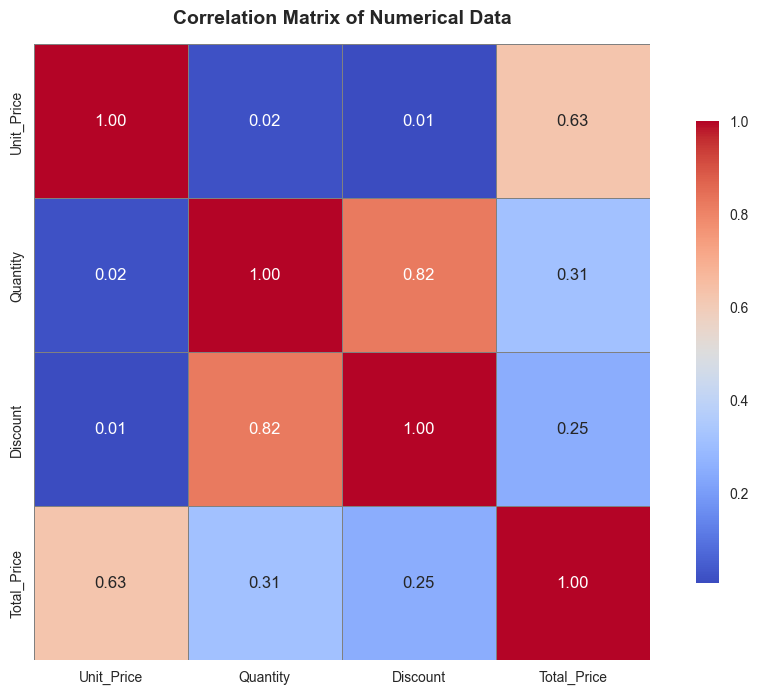

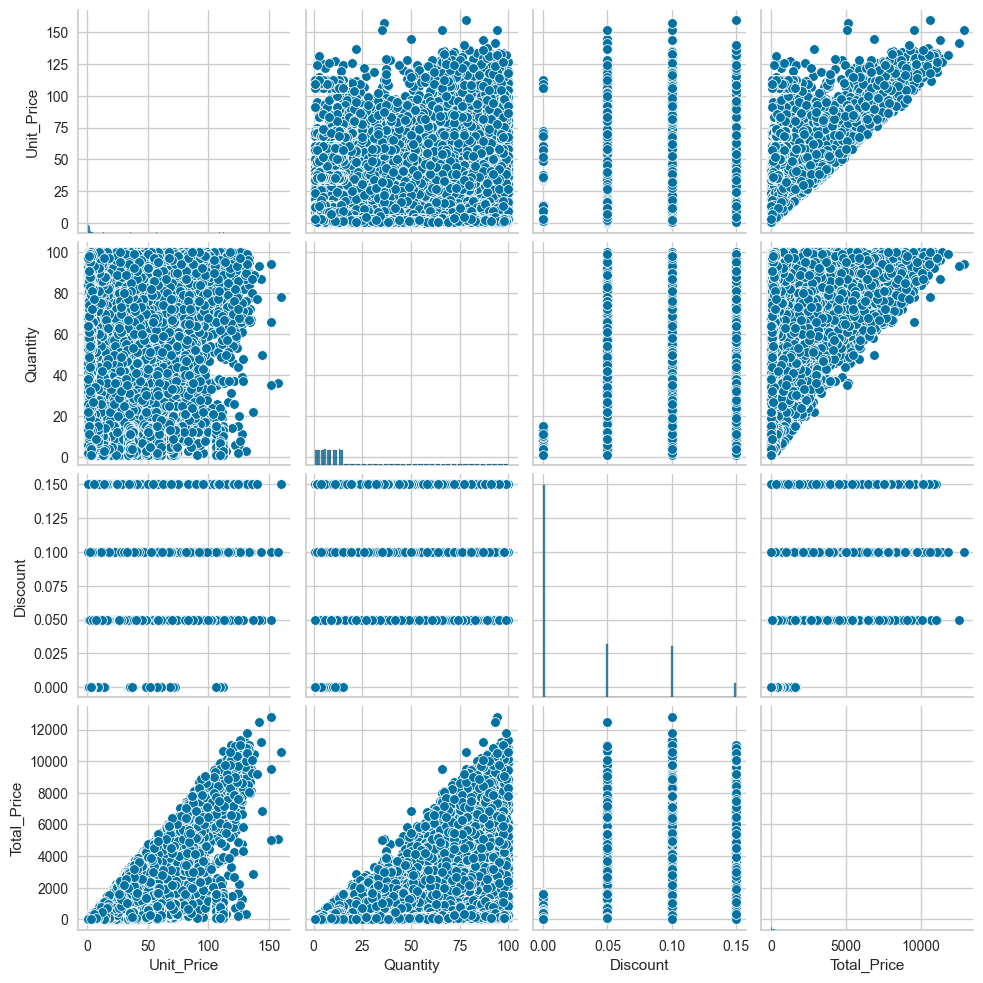

C:\Users\crism\AppData\Local\Temp\ipykernel_36056\4094015541.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_count.values, y=product_count.index, ax=axes[1, 0], palette="viridis")
C:\Users\crism\AppData\Local\Temp\ipykernel_36056\4094015541.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_count.values, y=region_count.index, ax=axes[1, 1], palette="magma")


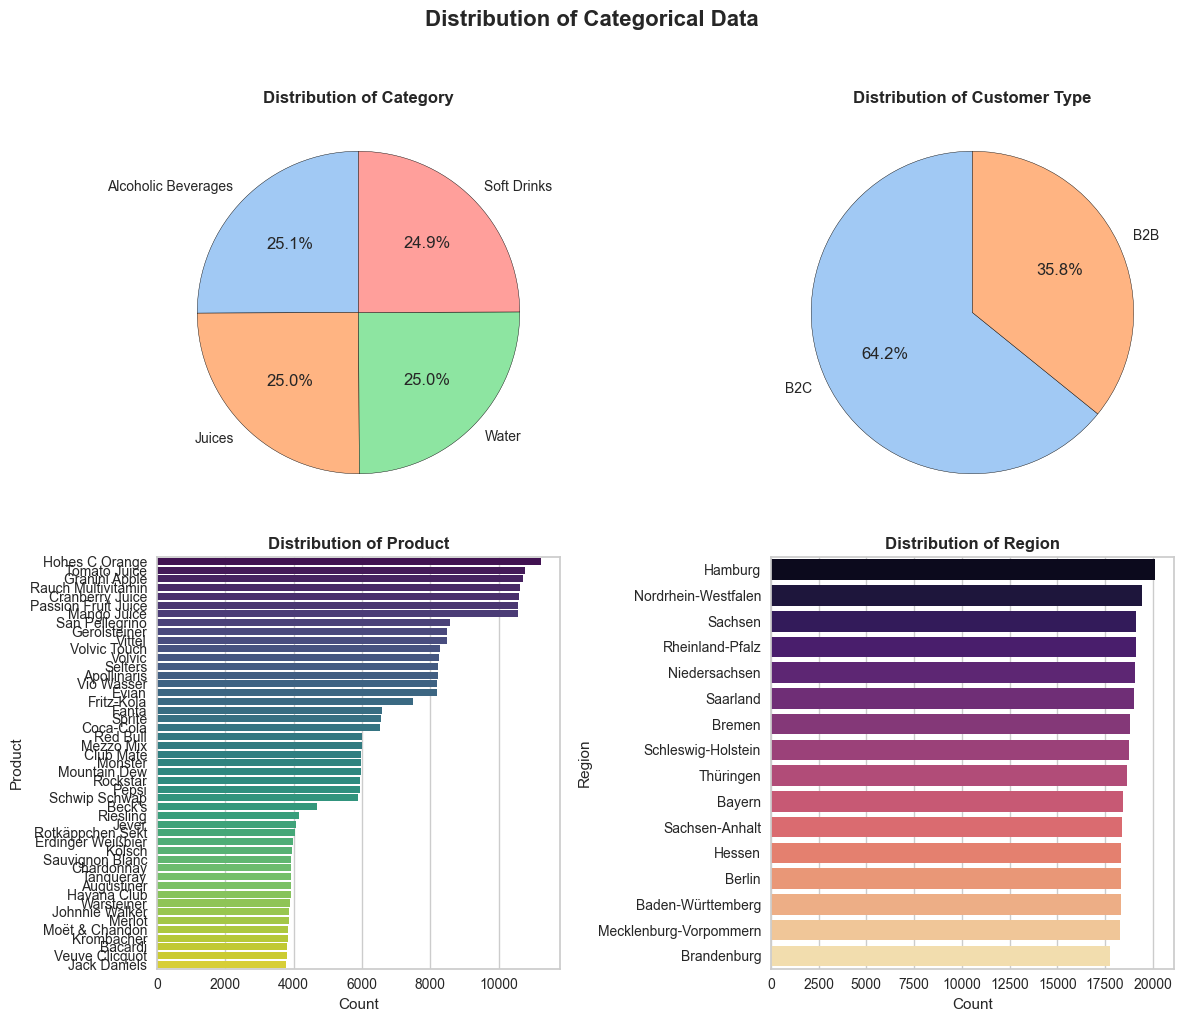

In [6]:
# Hitung matriks korelasi
correlation_matrix = df[numeric_columns].corr()

# Buat figure
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    linewidths=0.5, 
    linecolor='gray', 
    square=True, 
    cbar_kws={'shrink': 0.75}  # Mengecilkan color bar agar lebih proporsional
)

# Tambahkan judul dengan styling
plt.title('Correlation Matrix of Numerical Data', fontsize=14, fontweight='bold', pad=15)

# Tampilkan plot
plt.show()

# Periksa hubungan antara variabel dengan pairplot pada data numerik
sns.pairplot(df[numeric_columns])
plt.show()

# Ambil nama kolom data kategorikal
categorical_columns = ['Category', 'Customer_Type', 'Product', 'Region']

# Buat figure dengan ukuran yang lebih proporsional
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Warna untuk pie chart
colors = sns.color_palette('pastel')

# Diagram distribusi Category (Pie Chart)
category_count = df['Category'].value_counts()
axes[0, 0].pie(category_count, labels=category_count.index, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'edgecolor': 'black'})
axes[0, 0].set_title('Distribution of Category', fontsize=12, fontweight='bold')

# Diagram distribusi Customer_Type (Pie Chart)
customer_type_count = df['Customer_Type'].value_counts()
axes[0, 1].pie(customer_type_count, labels=customer_type_count.index, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'edgecolor': 'black'})
axes[0, 1].set_title('Distribution of Customer Type', fontsize=12, fontweight='bold')

# Diagram distribusi Product (Horizontal Bar Chart)
product_count = df['Product'].value_counts()
sns.barplot(x=product_count.values, y=product_count.index, ax=axes[1, 0], palette="viridis")
axes[1, 0].set_title('Distribution of Product', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Count")

# Diagram distribusi Region (Horizontal Bar Chart)
region_count = df['Region'].value_counts()
sns.barplot(x=region_count.values, y=region_count.index, ax=axes[1, 1], palette="magma")
axes[1, 1].set_title('Distribution of Region', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Count")

# Tambahkan judul utama
plt.suptitle("Distribution of Categorical Data", fontsize=16, fontweight='bold', y=1.02)

# Rapiin layout
plt.tight_layout()
plt.show()


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

# 1. Menghapus atau Menangani Data Kosong

In [7]:
# 1. Menghapus atau Menangani Data Kosong
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print("Jumlah data kosong per kolom:")
if missing_values.empty:
    print("Tidak ada data kosong dalam dataset.")
else:
    print(missing_values)

Jumlah data kosong per kolom:
Tidak ada data kosong dalam dataset.


# 2. Menghapus Data Duplikat

In [8]:
num_duplicates = df.duplicated().sum()
if num_duplicates > 0:
    print(f"Terdapat {num_duplicates} baris duplikat dalam dataset.")
    df = df.drop_duplicates()
else:
    print("Tidak ada data duplikat dalam dataset.")


Tidak ada data duplikat dalam dataset.


# 3. Normalisasi atau Standarisasi Fitur

In [9]:
# Inisialisasi fungsi normalisasi dan standarisasi
min_max_scaler = MinMaxScaler() # normalisasi
standard_scaler = StandardScaler() # standarisasi


In [10]:
# Normalisasi data
df_normalized = df.copy()
df_normalized[['Quantity']] = min_max_scaler.fit_transform(df_normalized[['Quantity']])
df_normalized.head()

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,ORD697566,CUS6363,B2C,Coca-Cola,Soft Drinks,1.04,0.060606,0.00,7.28,Bremen,2021-02-17
1,ORD1118443,CUS7797,B2B,Selters,Water,0.71,0.454545,0.10,29.39,Sachsen-Anhalt,2023-04-15
2,ORD742327,CUS3123,B2B,Fritz-Kola,Soft Drinks,2.90,0.727273,0.05,201.11,Sachsen,2022-06-20
3,ORD1437128,CUS6393,B2B,Monster,Soft Drinks,2.68,0.292929,0.05,76.38,Schleswig-Holstein,2021-09-07
4,ORD562794,CUS4090,B2C,San Pellegrino,Water,0.91,0.020202,0.00,2.73,Hessen,2023-04-28


In [11]:
# Standarisasi data
df_standardized = df_normalized.copy()
df_standardized[['Total_Price', 'Unit_Price']] = standard_scaler.fit_transform(df_standardized[['Total_Price', 'Unit_Price']])
df_standardized.head()

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,ORD697566,CUS6363,B2C,Coca-Cola,Soft Drinks,-0.325509,0.060606,0.00,-0.242710,Bremen,2021-02-17
1,ORD1118443,CUS7797,B2B,Selters,Water,-0.347963,0.454545,0.10,-0.199677,Sachsen-Anhalt,2023-04-15
2,ORD742327,CUS3123,B2B,Fritz-Kola,Soft Drinks,-0.198950,0.727273,0.05,0.134543,Sachsen,2022-06-20
3,ORD1437128,CUS6393,B2B,Monster,Soft Drinks,-0.213920,0.292929,0.05,-0.108220,Schleswig-Holstein,2021-09-07
4,ORD562794,CUS4090,B2C,San Pellegrino,Water,-0.334354,0.020202,0.00,-0.251566,Hessen,2023-04-28


# 4. Deteksi dan Penanganan Outlier

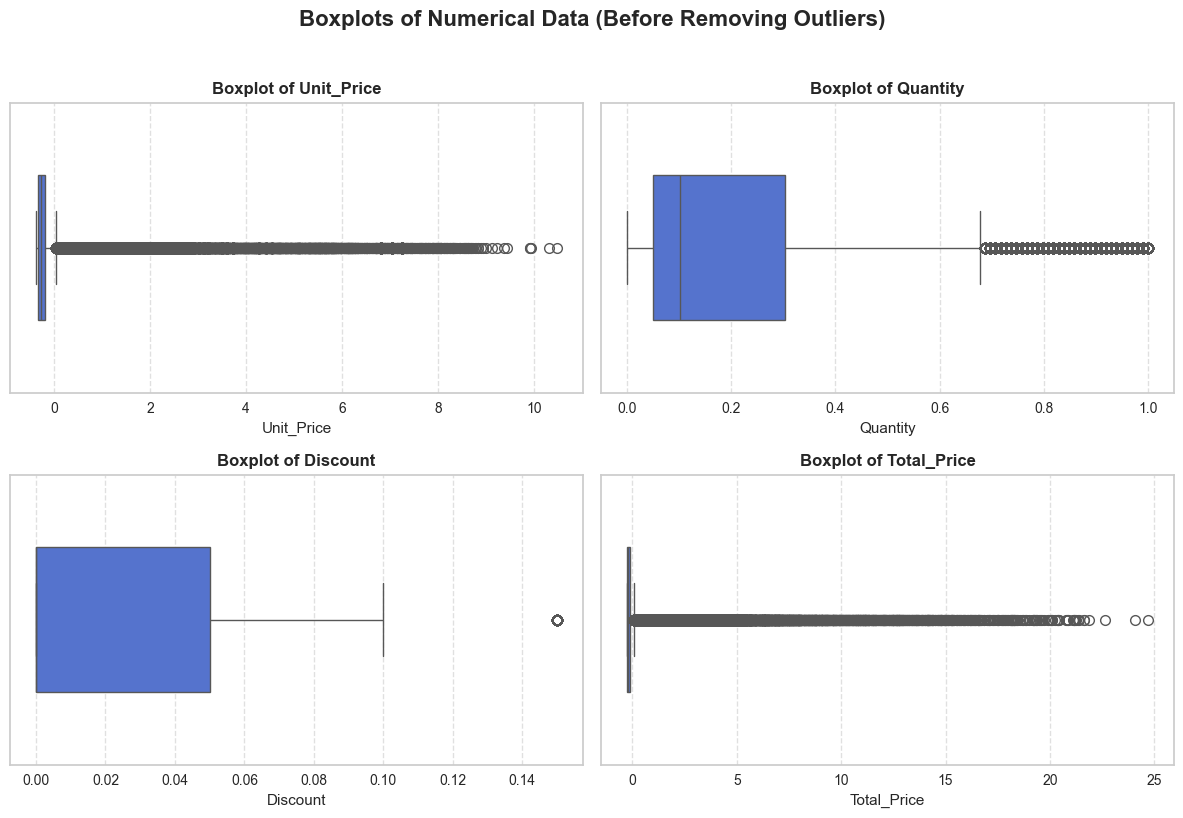

Jumlah data sebelum menghapus outlier: 300000


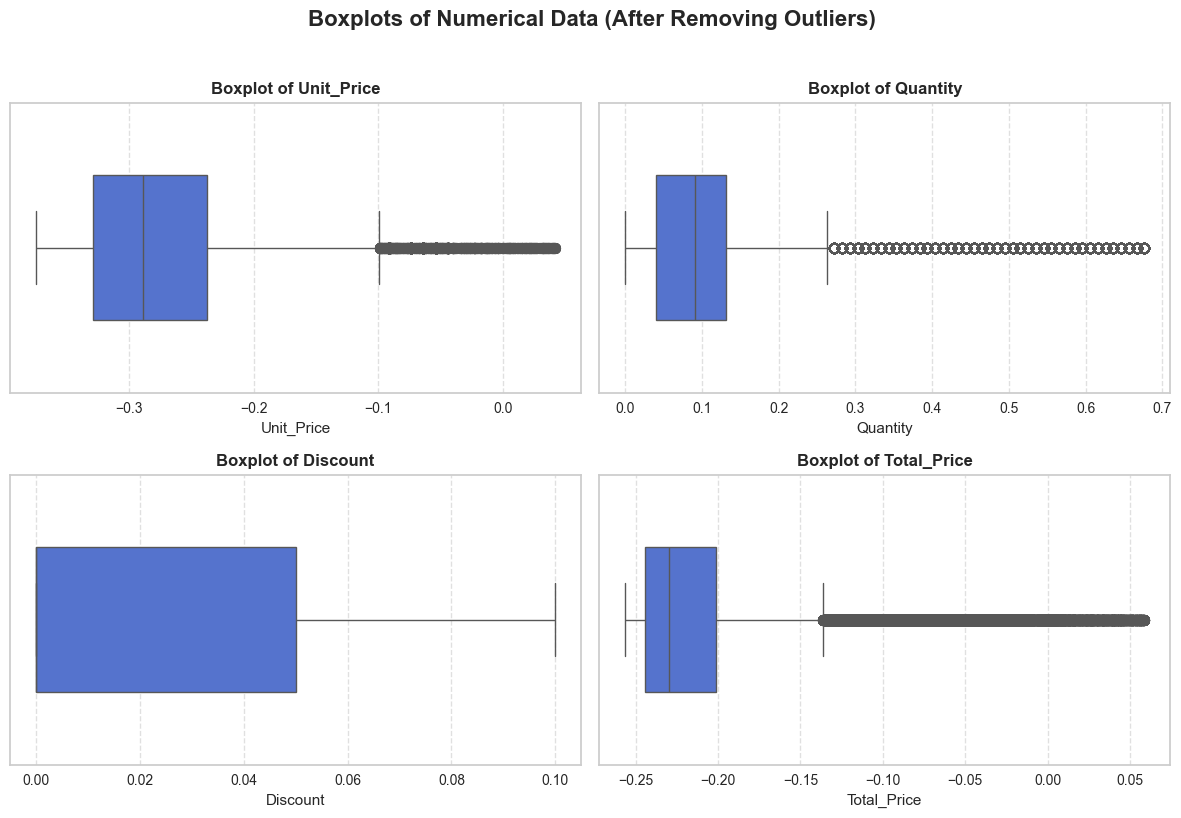

Jumlah data setelah menghapus outlier: 227858


In [12]:
# Menghitung Q1, Q3, dan IQR hanya untuk kolom numerik
Q1 = df_standardized[numeric_columns].quantile(0.25)
Q3 = df_standardized[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas bawah dan atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Fungsi untuk membuat boxplot yang lebih rapi
def plot_boxplots(data, title):
    n = len(numeric_columns)
    rows = (n // 2) + (n % 2)  # Menyesuaikan jumlah baris agar tidak ada subplot kosong
    fig, axes = plt.subplots(rows, 2, figsize=(12, rows * 4))

    # Flatten axes jika hanya ada satu baris
    axes = axes.flatten() if n > 1 else [axes]

    for i, col in enumerate(numeric_columns):
        sns.boxplot(x=data[col], ax=axes[i], color='royalblue', width=0.5)
        axes[i].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
        axes[i].grid(axis='x', linestyle='--', alpha=0.6)

    # Hapus subplot kosong jika jumlah kolom ganjil
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Menampilkan boxplot sebelum menghapus outlier
plot_boxplots(df_standardized, "Boxplots of Numerical Data (Before Removing Outliers)")

print("Jumlah data sebelum menghapus outlier:", df_standardized.shape[0])

# Menghapus outlier pada kolom numerik
mask = ~((df_standardized[numeric_columns] < lower_bound) | (df_standardized[numeric_columns] > upper_bound)).any(axis=1)
df_cleaned = df_standardized[mask]

# Menampilkan boxplot setelah menghapus outlier
plot_boxplots(df_cleaned, "Boxplots of Numerical Data (After Removing Outliers)")

print("Jumlah data setelah menghapus outlier:", df_cleaned.shape[0])


# 5. Encoding Data Kategorikal

In [13]:
# Inisialisasi LabelEncoder
label_encoder = LabelEncoder()

# Salin dataframe agar tidak mengubah data asli
df_labeled = df_cleaned.copy()

# Label encoding untuk kolom kategorikal tertentu
for col in ['Category', 'Region', 'Product']:
    df_labeled[col] = label_encoder.fit_transform(df_cleaned[col])

# One-hot encoding untuk 'Customer_Type'
df_encoded = pd.get_dummies(df_labeled, columns=['Customer_Type'])

# Tampilkan 5 baris pertama
df_encoded.head()


,Order_ID,Customer_ID,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,Customer_Type_B2B,Customer_Type_B2C
0,ORD697566,CUS6363,5,2,-0.325509,0.060606,0.00,-0.242710,4,2021-02-17,False,True
1,ORD1118443,CUS7797,32,3,-0.347963,0.454545,0.10,-0.199677,13,2023-04-15,True,False
3,ORD1437128,CUS6393,20,2,-0.213920,0.292929,0.05,-0.108220,14,2021-09-07,True,False
4,ORD562794,CUS4090,29,3,-0.334354,0.020202,0.00,-0.251566,6,2023-04-28,False,True
5,ORD2320519,CUS5936,2,0,-0.300333,0.030303,0.00,-0.245902,4,2023-11-01,False,True


# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan. Berikut adalah **rekomendasi** tahapannya.
1. Pilih algoritma clustering yang sesuai.
2. Latih model dengan data menggunakan algoritma tersebut.

In [14]:
### 6. Pembangunan Model Clustering

#### a. Pembangunan Model Clustering

# 1. Pilih algoritma clustering yang sesuai

# Pastikan semua fitur yang dipilih ada dalam DataFrame
selected_features = ['Unit_Price', 'Quantity', 'Discount', 'Total_Price', 'Customer_Type_B2B', 'Customer_Type_B2C']

# Cek apakah semua fitur ada dalam df_encoded untuk menghindari KeyError
missing_features = [feat for feat in selected_features if feat not in df_encoded.columns]
if missing_features:
    print(f"Warning: Fitur berikut tidak ditemukan dalam DataFrame: {missing_features}")

# Ambil fitur yang tersedia
X = df_encoded[selected_features] if not missing_features else df_encoded.dropna(subset=selected_features, errors='ignore')

# Tampilkan beberapa baris pertama
X.head()

# 2. Latih model dengan data menggunakan algoritma clustering yang dipilih

# Inisialisasi model KMeans dengan random_state untuk hasil yang konsisten
kmeans = KMeans(n_init=10, random_state=42)

## **b. Evaluasi Model Clustering**

Untuk menentukan jumlah cluster yang optimal dalam model clustering, Anda dapat menggunakan metode Elbow atau Silhouette Score.

Metode ini membantu kita menemukan jumlah cluster yang memberikan pemisahan terbaik antar kelompok data, sehingga model yang dibangun dapat lebih efektif. Berikut adalah **rekomendasi** tahapannya.
1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal.
2. Hitung Silhouette Score sebagai ukuran kualitas cluster.

2. Hitung Silhouette Score sebagai ukuran kualitas cluster

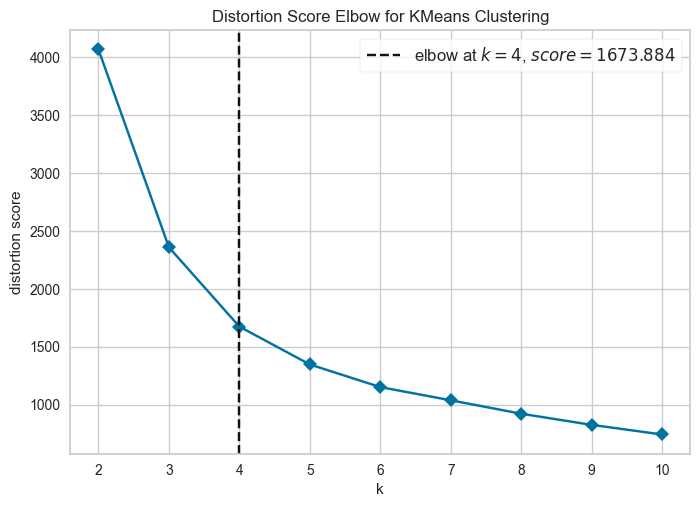

Silhouette Score for K=4: 0.8661793593002011


In [15]:
#### b. Evaluasi Model Clustering

# 1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal

# Inisialisasi visualizer KElbow untuk menentukan jumlah cluster optimal
visualizer = KElbowVisualizer(kmeans, k=(2, 11), metric='distortion', timings=False)

# Fit visualizer dengan data untuk menemukan jumlah cluster optimal
visualizer.fit(X)

# Menampilkan grafik elbow untuk analisis
visualizer.show()

# Ambil nilai k optimal dari Elbow method
optimal_k = visualizer.elbow_value_

# Pastikan optimal_k ditemukan sebelum melanjutkan
if optimal_k is None:
    raise ValueError("Gagal menentukan jumlah cluster optimal. Pastikan visualizer.fit(X) telah dijalankan.")

# Inisialisasi PCA untuk mengurangi dimensi ke 2 komponen utama
pca = PCA(n_components=2, random_state=42)

# Terapkan PCA ke data
X_pca = pca.fit_transform(X)

# Simpan hasil ke dalam DataFrame untuk kemudahan analisis
df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])

# Tampilkan beberapa baris pertama
df_pca.head()

# 2. Hitung Silhouette Score sebagai ukuran kualitas cluster

# Inisialisasi dan fit model KMeans dengan k optimal
kmeans = KMeans(n_clusters=optimal_k, random_state=69, init='k-means++', n_init=10)
kmeans.fit(X_pca)

# Hitung Silhouette Score
sil_score = silhouette_score(X_pca, kmeans.labels_)
print(f'Silhouette Score for K={optimal_k}: {sil_score}')


## **c. Feature Selection (Opsional)**

Silakan lakukan feature selection jika Anda membutuhkan optimasi model clustering. Jika Anda menerapkan proses ini, silakan lakukan pemodelan dan evaluasi kembali menggunakan kolom-kolom hasil feature selection. Terakhir, bandingkan hasil performa model sebelum dan sesudah menerapkan feature selection.

In [16]:
# Standarisasi data sebelum feature selection
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Gunakan SelectKBest untuk memilih fitur terbaik (misalnya, 4 fitur terbaik)
k_best = SelectKBest(score_func=mutual_info_regression, k=4)
X_selected = k_best.fit_transform(X_scaled, kmeans.labels_)

# Lihat fitur yang dipilih
selected_indices = k_best.get_support(indices=True)
selected_features = [selected_features[i] for i in selected_indices]
print("Fitur yang dipilih:", selected_features)

# Lakukan PCA kembali setelah Feature Selection
X_pca_selected = pca.fit_transform(X_selected)
df_pca_selected = pd.DataFrame(X_pca_selected, columns=['PCA1', 'PCA2'])

# Clustering ulang dengan fitur yang telah dipilih
kmeans_selected = KMeans(n_clusters=optimal_k, random_state=69, init='k-means++', n_init=10)
kmeans_selected.fit(X_pca_selected)

# Hitung Silhouette Score setelah Feature Selection
sil_score_selected = silhouette_score(X_pca_selected, kmeans_selected.labels_)
print(f'Silhouette Score setelah Feature Selection: {sil_score_selected}')

# Bandingkan dengan hasil sebelumnya
print("Perbandingan Silhouette Score:")
print(f"  - Sebelum Feature Selection: {sil_score}")
print(f"  - Setelah Feature Selection: {sil_score_selected}")

Fitur yang dipilih: ['Quantity', 'Discount', 'Customer_Type_B2B', 'Customer_Type_B2C']
Silhouette Score setelah Feature Selection: 0.8045125262852041
Perbandingan Silhouette Score:
  - Sebelum Feature Selection: 0.8661793593002011
  - Setelah Feature Selection: 0.8045125262852041


## **d. Visualisasi Hasil Clustering**

Setelah model clustering dilatih dan jumlah cluster optimal ditentukan, langkah selanjutnya adalah menampilkan hasil clustering melalui visualisasi.

Berikut adalah **rekomendasi** tahapannya.
1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti grafik scatter plot atau 2D PCA projection.

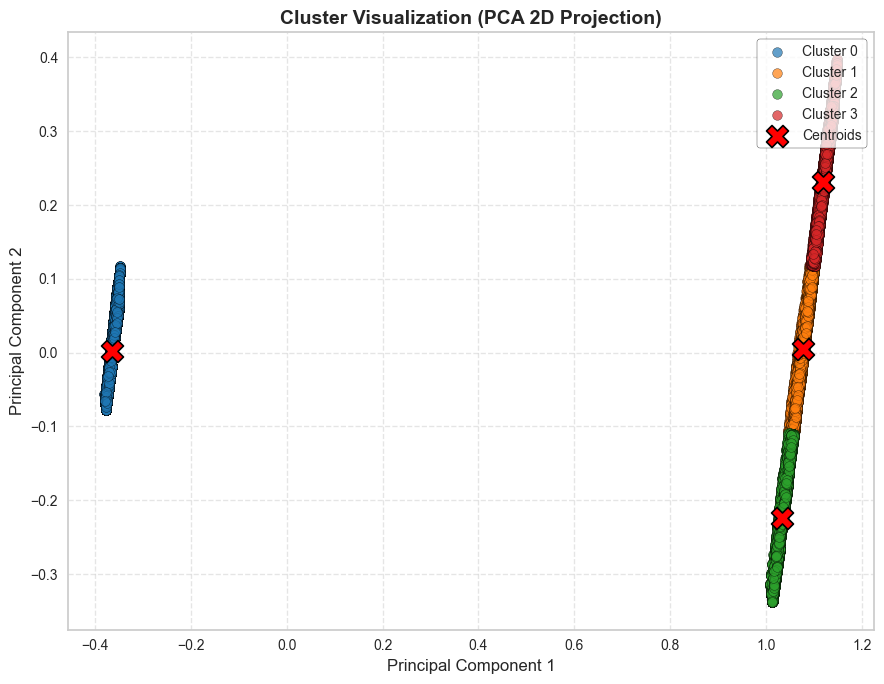

In [17]:
# Tentukan jumlah cluster
num_clusters = optimal_k

# Buat figure untuk visualisasi
fig, ax = plt.subplots(figsize=(9, 7))

# Gunakan palet warna seaborn agar lebih estetik
palette = sns.color_palette("tab10", num_clusters)

# Plot setiap klaster dengan warna berbeda
for i in range(num_clusters):
    ax.scatter(
        X_pca[kmeans.labels_ == i, 0], X_pca[kmeans.labels_ == i, 1],
        color=palette[i], label=f'Cluster {i}', alpha=0.7, edgecolors='black'
    )

# Plot centroid
ax.scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
    c='red', marker='X', s=250, label='Centroids', edgecolors='black', linewidth=1.2
)

# Tambahkan elemen desain
ax.set_title('Cluster Visualization (PCA 2D Projection)', fontsize=14, fontweight='bold')
ax.set_xlabel('Principal Component 1', fontsize=12)
ax.set_ylabel('Principal Component 2', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

# Tambahkan legenda
ax.legend(loc='upper right', fontsize=10, frameon=True, edgecolor='black')

# Tampilkan plot
plt.tight_layout()
plt.show()


## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

**Tutorial: Melakukan Inverse Transform pada Data Target Setelah Clustering**

Setelah melakukan clustering dengan model **KMeans**, kita perlu mengembalikan data yang telah diubah (normalisasi, standarisasi, atau label encoding) ke bentuk aslinya. Berikut adalah langkah-langkahnya.

---

**1. Tambahkan Hasil Label Cluster ke DataFrame**
Setelah mendapatkan hasil clustering, kita tambahkan label cluster ke dalam DataFrame yang telah dinormalisasi.

```python
df_normalized['Cluster'] = model_kmeans.labels_
```

Lakukan Inverse Transform pada feature yang sudah dilakukan Labelisasi dan Standararisasi. Berikut code untuk melakukannya:
label_encoder.inverse_transform(X_Selected[['Fitur']])

Lalu masukkan ke dalam kolom dataset asli atau membuat dataframe baru
```python
df_normalized['Fitur'] = label_encoder.inverse_transform(df_normalized[['Fitur']])
```
Masukkan Data yang Sudah Di-Inverse ke dalam Dataset Asli atau Buat DataFrame Baru
```python
df_original['Fitur'] = df_normalized['Fitur']
```

1️⃣ Tambahkan Hasil Label Cluster ke DataFrame

In [18]:
# Salin data setelah penanganan outlier
df_clustered = df_cleaned.copy()

# Tambahkan hasil clustering ke dalam dataset
df_clustered['Cluster'] = kmeans.labels_

# Tampilkan 5 baris pertama setelah penambahan label cluster
df_clustered.head()


,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,Cluster
0,ORD697566,CUS6363,B2C,Coca-Cola,Soft Drinks,-0.325509,0.060606,0.00,-0.242710,Bremen,2021-02-17,0
1,ORD1118443,CUS7797,B2B,Selters,Water,-0.347963,0.454545,0.10,-0.199677,Sachsen-Anhalt,2023-04-15,1
3,ORD1437128,CUS6393,B2B,Monster,Soft Drinks,-0.213920,0.292929,0.05,-0.108220,Schleswig-Holstein,2021-09-07,1
4,ORD562794,CUS4090,B2C,San Pellegrino,Water,-0.334354,0.020202,0.00,-0.251566,Hessen,2023-04-28,0
5,ORD2320519,CUS5936,B2C,Beck's,Alcoholic Beverages,-0.300333,0.030303,0.00,-0.245902,Bremen,2023-11-01,0


2️⃣ Inverse Transform untuk Mengembalikan Data ke Skala Asli

In [19]:
# Salin dataframe setelah penanganan outlier
df_labeled = df_cleaned.copy()

# Tambahkan hasil clustering ke dalam dataframe
df_labeled['Cluster'] = kmeans.labels_

# Tampilkan 5 baris pertama setelah menambahkan cluster
df_labeled.head()

# Kembalikan data numerik ke skala aslinya
df_labeled['Quantity'] = min_max_scaler.inverse_transform(df_labeled[['Quantity']])

df_labeled[['Total_Price', 'Unit_Price']] = standard_scaler.inverse_transform(
    df_labeled[['Total_Price', 'Unit_Price']]
)

# Tampilkan hasil akhir
df_labeled.head()


,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,Cluster
0,ORD697566,CUS6363,B2C,Coca-Cola,Soft Drinks,1.04,7.0,0.00,7.28,Bremen,2021-02-17,0
1,ORD1118443,CUS7797,B2B,Selters,Water,0.71,46.0,0.10,29.39,Sachsen-Anhalt,2023-04-15,1
3,ORD1437128,CUS6393,B2B,Monster,Soft Drinks,2.68,30.0,0.05,76.38,Schleswig-Holstein,2021-09-07,1
4,ORD562794,CUS4090,B2C,San Pellegrino,Water,0.91,3.0,0.00,2.73,Hessen,2023-04-28,0
5,ORD2320519,CUS5936,B2C,Beck's,Alcoholic Beverages,1.41,4.0,0.00,5.64,Bremen,2023-11-01,0


### Inverse Data Jika Melakukan Normalisasi/Standardisasi

Inverse Transform untuk Data yang Distandarisasi
Jika data numerik telah dinormalisasi menggunakan StandardScaler atau MinMaxScaler, kita bisa mengembalikannya ke skala asli:
```python
df_normalized[['Fitur_Numerik']] = scaler.inverse_transform(df_normalized[['Fitur_Numerik']])
```

In [20]:
# Lakukan inverse transform untuk mengembalikan skala asli data numerik
df_labeled['Quantity'] = min_max_scaler.inverse_transform(df_labeled[['Quantity']])
df_labeled[['Total_Price', 'Unit_Price']] = standard_scaler.inverse_transform(df_labeled[['Total_Price', 'Unit_Price']])

# Tampilkan hasil
print("Data setelah dikembalikan ke skala aslinya:")
display(df_labeled.head())

Data setelah dikembalikan ke skala aslinya:


,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,Cluster
0,ORD697566,CUS6363,B2C,Coca-Cola,Soft Drinks,21.108543,694.0,0.00,3872.400320,Bremen,2021-02-17,0
1,ORD1118443,CUS7797,B2B,Selters,Water,16.258615,4555.0,0.10,15232.377055,Sachsen-Anhalt,2023-04-15,1
3,ORD1437128,CUS6393,B2B,Monster,Soft Drinks,45.211213,2971.0,0.05,39375.538829,Schleswig-Holstein,2021-09-07,1
4,ORD562794,CUS4090,B2C,San Pellegrino,Water,19.197965,298.0,0.00,1534.639390,Hessen,2023-04-28,0
5,ORD2320519,CUS5936,B2C,Beck's,Alcoholic Beverages,26.546340,397.0,0.00,3029.778798,Bremen,2023-11-01,0


Setelah melakukan clustering, langkah selanjutnya adalah menganalisis karakteristik dari masing-masing cluster berdasarkan fitur yang tersedia.

Berikut adalah **rekomendasi** tahapannya.
1. Analisis karakteristik tiap cluster berdasarkan fitur yang tersedia (misalnya, distribusi nilai dalam cluster).
2. Berikan interpretasi: Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis? Apakah ada pola tertentu yang bisa dimanfaatkan?

4️⃣ Analisis Karakteristik Tiap Cluster

In [21]:
# Tentukan fitur numerik yang akan digunakan dalam clustering
features = ['Unit_Price', 'Quantity', 'Total_Price']

# Cek apakah 'Cluster' sudah ada di df_labeled
if 'Cluster' not in df_labeled.columns:
    print("❌ Kolom 'Cluster' tidak ditemukan. Mengecek sumber data...")

    # Coba ambil dari dataset lain jika tersedia
    if 'Cluster' in df_clustered.columns:
        print("✅ Kolom 'Cluster' ditemukan di df_clustered! Menyatukan dataset...")
        df_labeled = df_labeled.merge(df_clustered[['Order_ID', 'Cluster']], on='Order_ID', how='left')
    else:
        print("⚠️ Kolom 'Cluster' tidak ada di df_clustered. Melakukan clustering...")

5️⃣ Statistik Cluster (Jumlah Data per Cluster)


📊 Jumlah Data per Cluster:
 Cluster
0    170159
1     19762
2     20119
3     17818
Name: count, dtype: int64 



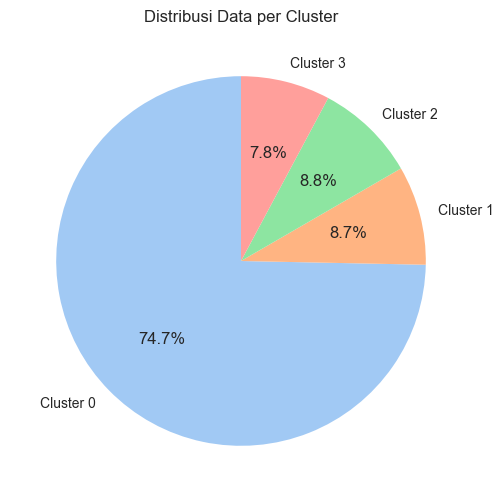

In [22]:
# Hitung jumlah data dalam setiap cluster
cluster_counts = df_labeled['Cluster'].value_counts().sort_index()
print("\n📊 Jumlah Data per Cluster:\n", cluster_counts, '\n')

# 🔹 Pie Chart Distribusi Cluster
plt.figure(figsize=(6, 6))
plt.pie(cluster_counts, labels=[f'Cluster {i}' for i in cluster_counts.index],
        autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.title('Distribusi Data per Cluster')
plt.show()


6️⃣ Rata-rata Fitur Numerik per Cluster

In [23]:
# Hitung rata-rata fitur numerik dalam setiap cluster
if 'Cluster' in df_labeled.columns:
    cluster_means = df_labeled.groupby('Cluster')[features].mean()
    print("\n📊 Rata-rata Fitur Numerik per Cluster:\n", cluster_means, '\n')
else:
    print("⚠️ Kolom 'Cluster' tidak ditemukan. Pastikan clustering sudah dilakukan.")



📊 Rata-rata Fitur Numerik per Cluster:
          Unit_Price     Quantity   Total_Price
Cluster                                       
0         33.005480   793.186179   7728.526009
1         29.447160  3333.275276  25177.187782
2         28.439145  1147.966102   8383.581261
3         29.605975  5514.202099  42014.160838 



7️⃣ Distribusi Customer Type per Cluster


📊 Distribusi Customer Type dalam Setiap Cluster:
 Customer_Type    B2B     B2C
Cluster                     
0                  0  170159
1              19762       0
2              20119       0
3              17818       0 



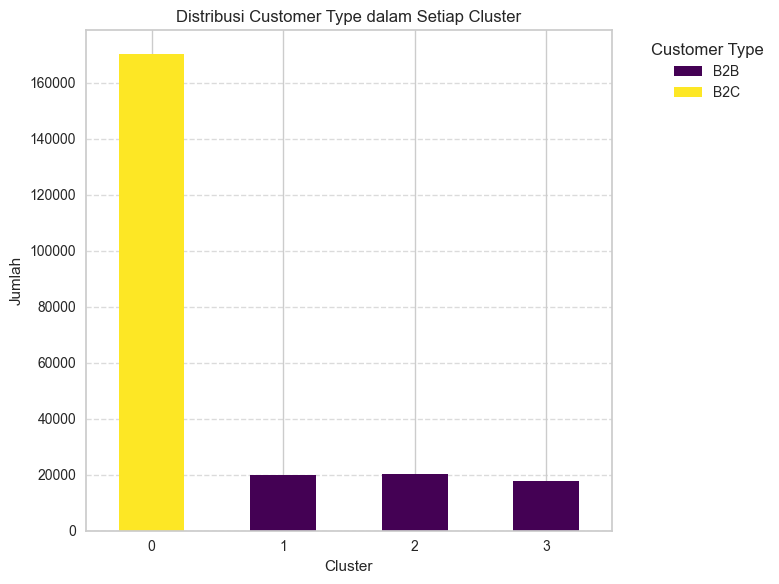

In [24]:
if 'Customer_Type' in df_labeled.columns:
    customer_cluster_counts = df_labeled.groupby(['Cluster', 'Customer_Type']).size().unstack(fill_value=0)
    print("\n📊 Distribusi Customer Type dalam Setiap Cluster:\n", customer_cluster_counts, '\n')

    # Visualisasi dengan stacked bar chart
    plt.figure(figsize=(8, 6))
    customer_cluster_counts.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())

    plt.title('Distribusi Customer Type dalam Setiap Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('Jumlah')
    plt.legend(title="Customer Type", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Kolom 'Customer_Type' tidak ditemukan, melewatkan analisis distribusi Customer Type.")


8️⃣ Interpretasi dan Kesimpulan

Tulis hasil interpretasinya di sini.
1. Cluster 1:
2. Cluster 2:
3. Cluster 3:

# Contoh interpretasi [TEMPLATE]
# Analisis Karakteristik Cluster dari Model KMeans

Berikut adalah analisis karakteristik untuk setiap cluster yang dihasilkan dari model KMeans.

## Cluster 1:
- **Rata-rata Annual Income (k$):** 48,260  
- **Rata-rata Spending Score (1-100):** 56.48  
- **Analisis:** Cluster ini mencakup pelanggan dengan pendapatan tahunan menengah dan tingkat pengeluaran yang cukup tinggi. Pelanggan dalam cluster ini cenderung memiliki daya beli yang moderat dan mereka lebih cenderung untuk membelanjakan sebagian besar pendapatan mereka.

## Cluster 2:
- **Rata-rata Annual Income (k$):** 86,540  
- **Rata-rata Spending Score (1-100):** 82.13  
- **Analisis:** Cluster ini menunjukkan pelanggan dengan pendapatan tahunan tinggi dan pengeluaran yang sangat tinggi. Pelanggan di cluster ini merupakan kelompok premium dengan daya beli yang kuat dan cenderung mengeluarkan uang dalam jumlah besar untuk produk atau layanan.

## Cluster 3:
- **Rata-rata Annual Income (k$):** 87,000  
- **Rata-rata Spending Score (1-100):** 18.63  
- **Analisis:** Cluster ini terdiri dari pelanggan dengan pendapatan tahunan yang tinggi tetapi pengeluaran yang rendah. Mereka mungkin memiliki kapasitas finansial yang baik namun tidak terlalu aktif dalam berbelanja. Ini bisa menunjukkan bahwa mereka lebih selektif dalam pengeluaran mereka atau mungkin lebih cenderung untuk menyimpan uang.

---

# Jawaban :

---

### **📊 Analisis Karakteristik Cluster dari Model KMeans**  

Berikut adalah analisis karakteristik untuk setiap cluster berdasarkan hasil KMeans clustering.  

## **Cluster 0 (B2C Dominan)**  
- **Proporsi Data:** 74.7% dari total data  
- **Rata-rata Unit Price:** $33.01  
- **Rata-rata Quantity:** 793 unit  
- **Rata-rata Total Price:** $7,728.53  
- **Customer Type:** 100% **B2C**  
- **Analisis:**  
  Cluster ini merupakan kelompok pelanggan **Business-to-Consumer (B2C)** dengan jumlah transaksi yang lebih kecil dibandingkan cluster lainnya. Mereka membeli dalam jumlah sedang dengan harga unit yang relatif lebih tinggi.  

## **Cluster 1 (B2B – Transaksi Sedang)**  
- **Proporsi Data:** 8.7% dari total data  
- **Rata-rata Unit Price:** $29.45  
- **Rata-rata Quantity:** 3,333 unit  
- **Rata-rata Total Price:** $25,177.19  
- **Customer Type:** 100% **B2B**  
- **Analisis:**  
  Cluster ini terdiri dari pelanggan **Business-to-Business (B2B)** dengan jumlah unit yang cukup tinggi per transaksi. Mereka melakukan pembelian dalam jumlah besar namun dengan harga per unit yang lebih rendah dibandingkan B2C.  

## **Cluster 2 (B2B – Transaksi Menengah)**  
- **Proporsi Data:** 8.8% dari total data  
- **Rata-rata Unit Price:** $28.44  
- **Rata-rata Quantity:** 1,147 unit  
- **Rata-rata Total Price:** $8,383.58  
- **Customer Type:** 100% **B2B**  
- **Analisis:**  
  Cluster ini memiliki pola pembelian yang lebih kecil dibandingkan Cluster 1, tetapi masih dalam kategori **B2B**. Harga unit sedikit lebih rendah dibandingkan Cluster 1, menunjukkan kemungkinan adanya negosiasi harga untuk pembelian dalam jumlah besar.  

## **Cluster 3 (B2B – Volume Besar)**  
- **Proporsi Data:** 7.8% dari total data  
- **Rata-rata Unit Price:** $29.61  
- **Rata-rata Quantity:** 5,514 unit  
- **Rata-rata Total Price:** $42,014.16  
- **Customer Type:** 100% **B2B**  
- **Analisis:**  
  Cluster ini merupakan pelanggan **B2B dengan transaksi terbesar**, memiliki jumlah pembelian tertinggi di antara semua cluster. Mereka cenderung membeli dalam jumlah yang sangat besar dengan harga unit yang kompetitif, sehingga total transaksi mereka jauh lebih tinggi dibandingkan cluster lainnya.  

---  

### **🚀 Insight dan Implikasi Bisnis:**  
📌 **Cluster 0 (B2C):** Strategi pemasaran bisa difokuskan pada promosi dan diskon retail.  
📌 **Cluster 1 & 2 (B2B):** Bisa ditawarkan diskon volume atau layanan eksklusif untuk meningkatkan loyalitas.  
📌 **Cluster 3 (B2B High Volume):** Berpotensi untuk program kemitraan jangka panjang atau penawaran harga khusus bagi pembelian besar.  

📊 **Segmentasi ini dapat digunakan untuk menyesuaikan strategi pemasaran dan penjualan agar lebih efektif sesuai dengan pola transaksi pelanggan.** 💡


---

### **📌 Kesimpulan dari Analisis Clustering**  

1️⃣ **Identifikasi Pola Pelanggan:**  
   - Clustering berhasil mengelompokkan pelanggan menjadi dua segmen utama: **B2C (Cluster 0)** dan **B2B (Cluster 1, 2, 3)**.  
   - **B2C (Cluster 0)** memiliki jumlah transaksi terbesar tetapi dengan volume per transaksi yang lebih kecil.  
   - **B2B (Cluster 1, 2, 3)** memiliki volume pembelian yang jauh lebih besar, dengan Cluster 3 sebagai pelanggan dengan transaksi tertinggi.  

2️⃣ **Strategi Pemasaran yang Lebih Tepat Sasaran:**  
   - **B2C (Cluster 0)** lebih cocok untuk strategi **promosi ritel, diskon, atau loyalitas pelanggan** guna meningkatkan repeat purchase.  
   - **B2B (Cluster 1-3)** memerlukan pendekatan yang lebih strategis seperti **diskon volume, kontrak eksklusif, atau layanan khusus** untuk mempertahankan hubungan bisnis jangka panjang.  

3️⃣ **Optimalisasi Harga dan Penawaran:**  
   - **B2C memiliki harga unit yang lebih tinggi**, sementara **B2B membeli dalam jumlah besar dengan harga lebih kompetitif**.  
   - Perusahaan dapat mengoptimalkan strategi harga dengan **menawarkan skema diskon berbasis volume untuk B2B** dan **harga premium dengan added value untuk B2C**.  

4️⃣ **Peluang Bisnis dan Ekspansi:**  
   - **Cluster 3 (B2B High Volume) memiliki potensi besar untuk menjadi mitra strategis** dengan pendekatan negosiasi khusus.  
   - **Cluster 1 & 2 dapat dikembangkan lebih lanjut dengan program loyalitas atau layanan tambahan** untuk meningkatkan engagement.  
   - **B2C bisa diperluas melalui strategi digital marketing dan customer retention** untuk meningkatkan frekuensi pembelian.  

📌 **Kesimpulan Utama:**  
Segmentasi pelanggan menggunakan KMeans telah memberikan wawasan mendalam tentang pola pembelian yang dapat digunakan untuk **mengoptimalkan strategi pemasaran, meningkatkan kepuasan pelanggan, serta memaksimalkan keuntungan bisnis secara efisien**. 🚀

---


# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [26]:
# Simpan dataframe ke dalam file CSV
df_labeled.to_csv('beverage_sales_clustering.csv', index=False)